# Lab 2

### Accel FFT

Sample rate:  245.9339576145885
T:  0.004066132264529058


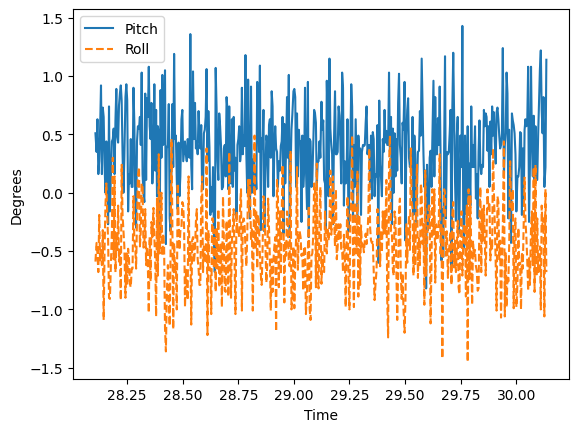

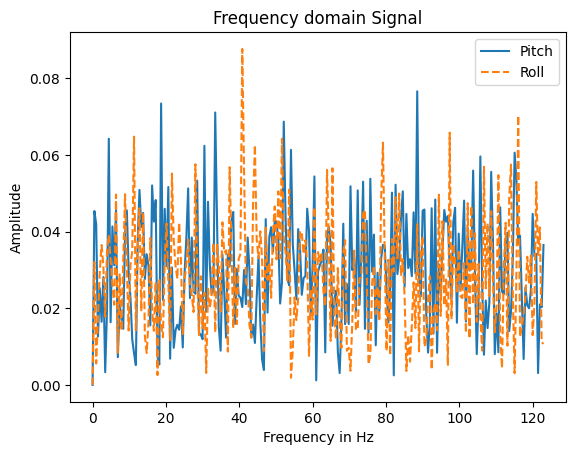

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("AccelNoiseNoDelay.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
print("T: ", T)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

### Calculating Alpha

In [30]:
from math import pi
from IPython.display import display, Markdown

fc = 25
T  = 0.004066132264529058

rc = 1/(2*pi*fc)
alpha = T/(T + rc)

md = rf"""
$$
RC = \frac{{1}}{{2\pi \cdot {fc}}}
    = {rc:.12g}
$$

$$
\alpha = \frac{{{T:.12g}}}{{{T:.12g} + {rc:.12g}}}
       = {alpha:.12g}
$$
"""
display(Markdown(md))



$$
RC = \frac{1}{2\pi \cdot 25}
    = 0.00636619772368
$$

$$
\alpha = \frac{0.00406613226453}{0.00406613226453 + 0.00636619772368}
       = 0.38976261958
$$


### Accel Low Pass FFT

Sample rate:  250.025012506253


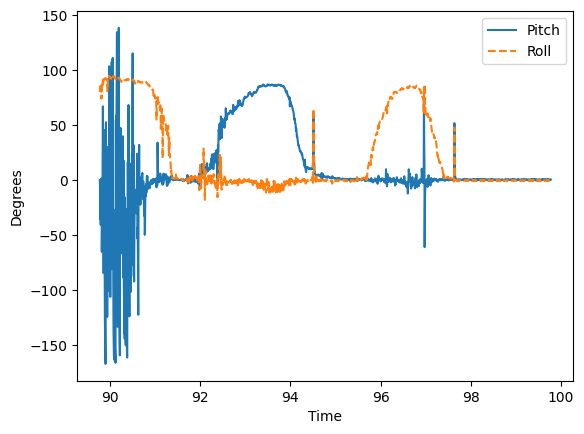

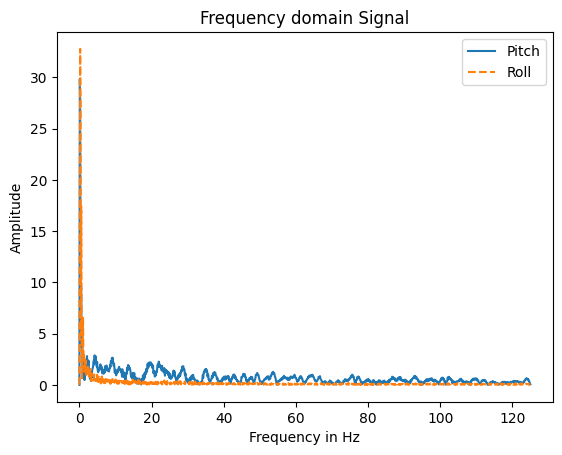

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("LowPass0.4ND2.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

### Low Pass and Original Values

Sample rate: 28.57142857142858


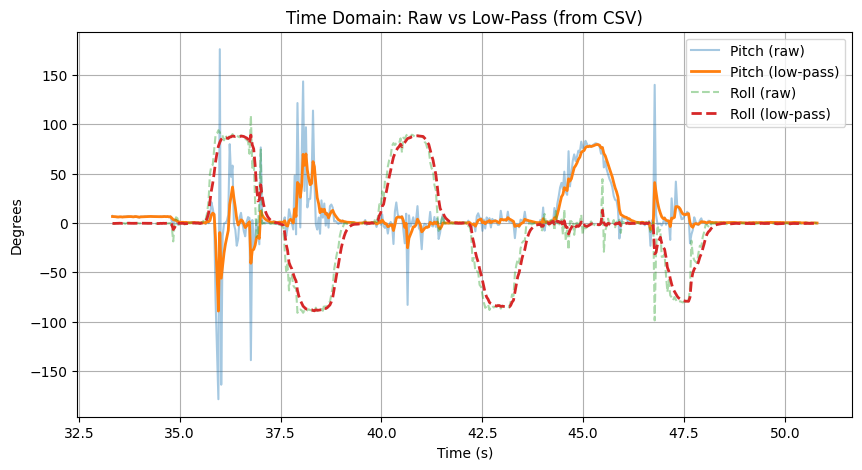

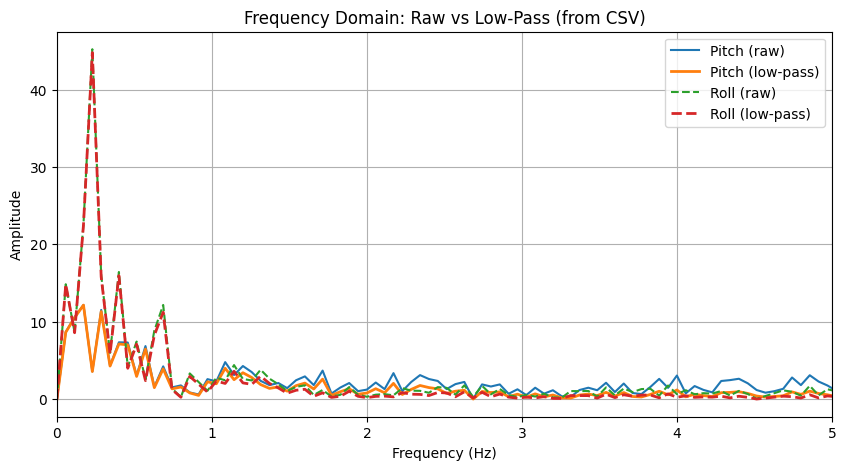

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ======================
# Load the CSV
# ======================
df = pd.read_csv("AllData.csv")

pitch    = df["Pitch"].to_numpy()
roll     = df["Roll"].to_numpy()
pitch_lp = df["Pitch_LPF"].to_numpy()
roll_lp  = df["Roll_LPF"].to_numpy()
t        = df["Time"].to_numpy() / 1000.0

# ======================
# Sample rate
# ======================
dt = np.diff(t)
T = np.mean(dt)
sample_rate = 1.0 / T
print("Sample rate:", sample_rate)

N = len(pitch)

# ======================
# Time-domain plot
# ======================
plt.figure(figsize=(10, 5))
plt.plot(t, pitch, label="Pitch (raw)", alpha=0.4)
plt.plot(t, pitch_lp, label="Pitch (low-pass)", linewidth=2)

plt.plot(t, roll, label="Roll (raw)", alpha=0.4, linestyle="--")
plt.plot(t, roll_lp, label="Roll (low-pass)", linewidth=2, linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("Time Domain: Raw vs Low-Pass (from CSV)")
plt.legend()
plt.grid(True)
plt.show()

# ======================
# Frequency-domain plot
# ======================
def spectrum(x):
    x0 = x - np.mean(x)
    X = np.fft.rfft(x0)
    return (2 / N) * np.abs(X)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

plt.figure(figsize=(10, 5))
plt.plot(frequency, spectrum(pitch), label="Pitch (raw)")
plt.plot(frequency, spectrum(pitch_lp), label="Pitch (low-pass)", linewidth=2)

plt.plot(frequency, spectrum(roll), label="Roll (raw)", linestyle="--")
plt.plot(frequency, spectrum(roll_lp), label="Roll (low-pass)", linestyle="--", linewidth=2)

plt.xlim(0, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain: Raw vs Low-Pass (from CSV)")
plt.legend()
plt.grid(True)
plt.show()


### Gyro Roll Pitch Yaw

Sample rate:  71.64564220183485
T:  0.013957583033213287


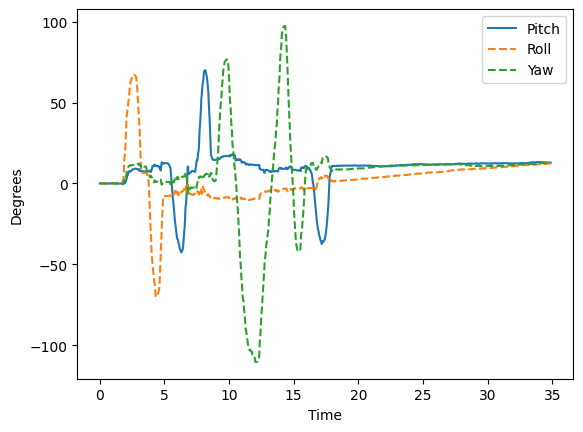

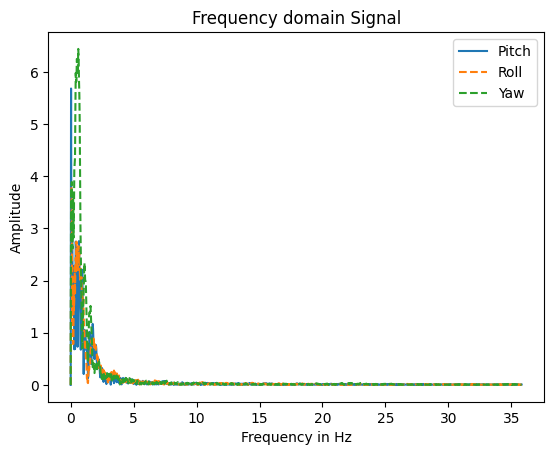

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("GyroRPY.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
yaw = df["Yaw"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
print("T: ", T)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.plot(t, yaw, label="Yaw", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)
yaw0  = yaw  - np.mean(yaw)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)
freq_yaw  = np.fft.rfft(yaw0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)
y_yaw = (2/N) * np.abs(freq_yaw)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.plot(frequency, y_yaw, label="Yaw", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

### Complementary Filter

Sample rate:  202.69283802417067
T:  0.004933573429371748


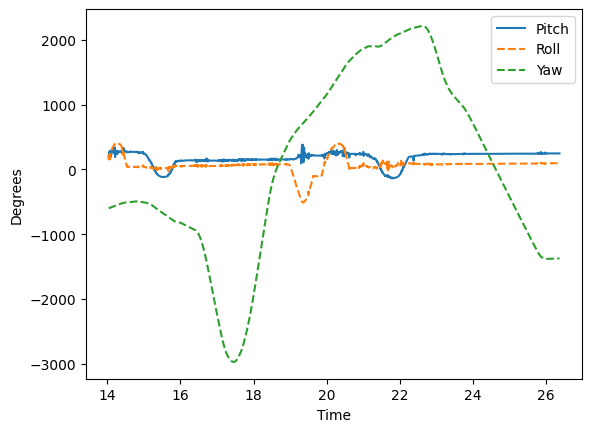

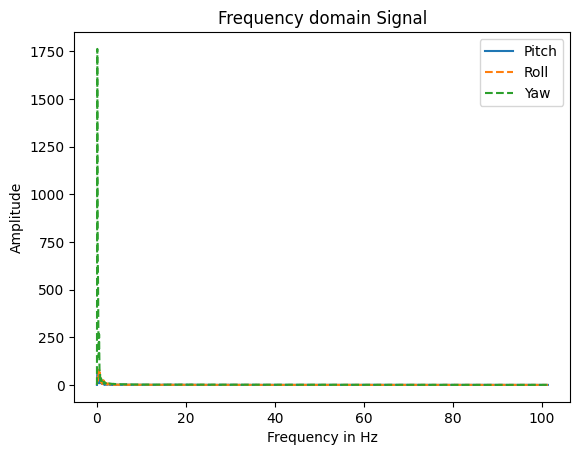

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("CompFilterOnly.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
yaw = df["Yaw"].to_numpy()
t     = df["Time"].to_numpy() / 1000.0   # ms -> s

# Compute time differences between samples
dt = np.diff(t)

# Average sample period
T = np.mean(dt)

# Sample rate
sample_rate = 1.0 / T
print("Sample rate: ", sample_rate)
print("T: ", T)
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.plot(t, yaw, label="Yaw", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)
yaw0  = yaw  - np.mean(yaw)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)
freq_yaw  = np.fft.rfft(yaw0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)
y_yaw = (2/N) * np.abs(freq_yaw)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.plot(frequency, y_yaw, label="Yaw", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()

## Comparing Comp Filter to Raw

Estimated sample_rate = 25.000 Hz   (T = 0.040000 s)


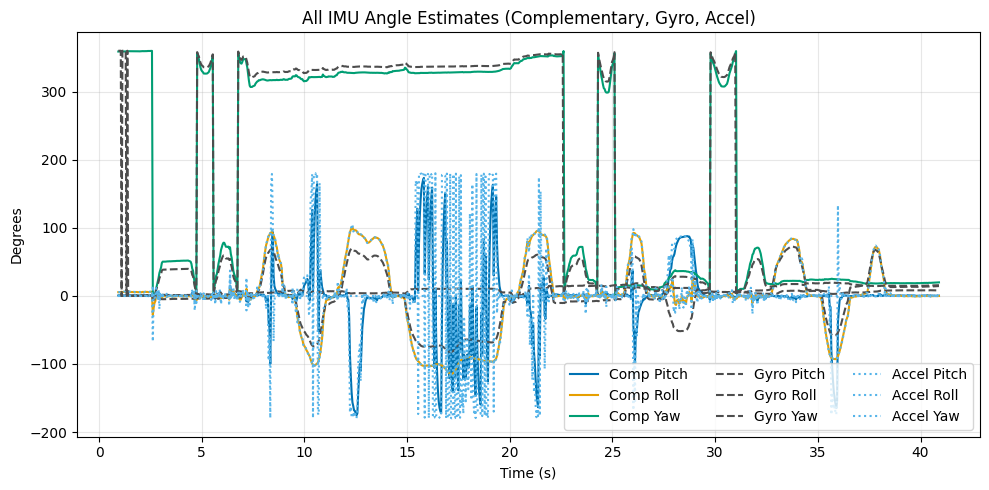

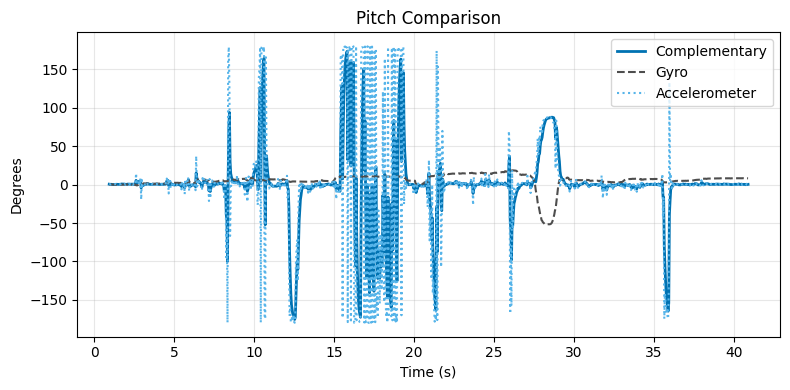

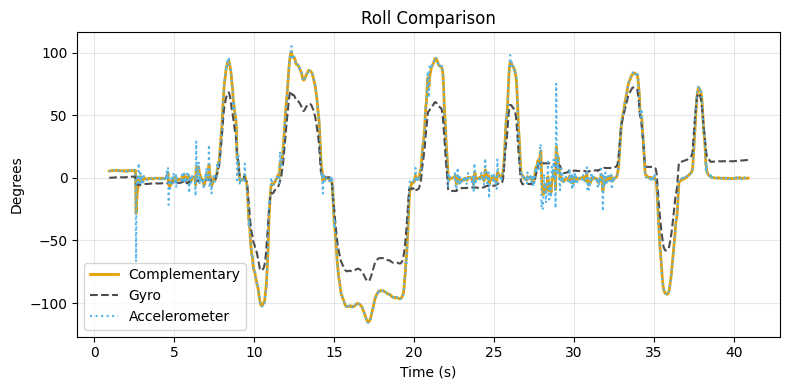


RMS errors vs ACCEL reference (degrees):
  Pitch: Comp vs Accel = 35.830 deg,  Gyro vs Accel = 68.117 deg
  Roll : Comp vs Accel = 3.730 deg,  Gyro vs Accel = 17.334 deg


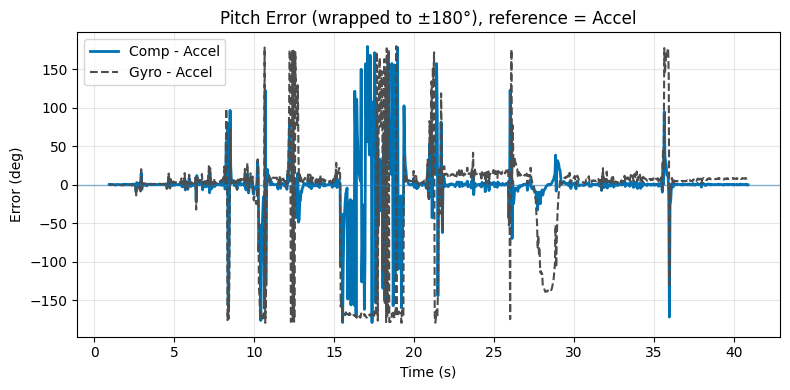

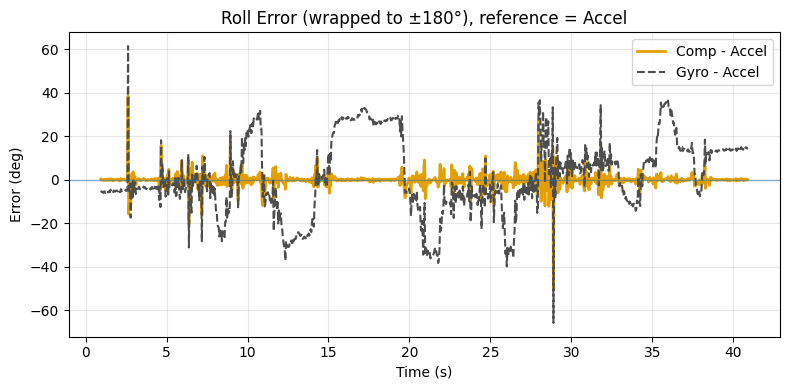

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Config / helpers
# -----------------------------
CSV_PATH = "AllDataNew.csv"

COLORS = {
    # Complementary filter (primary results)
    "comp_pitch": "#0072B2",  # blue
    "comp_roll":  "#E69F00",  # orange
    "comp_yaw":   "#009E73",  # bluish-green (safe, not pure green)

    # Raw sources
    "gyro":       "#4D4D4D",  # dark gray
    "accel":      "#56B4E9",  # light sky blue
}

def rms(x: np.ndarray) -> float:
    x = np.asarray(x)
    return float(np.sqrt(np.mean(x * x)))

def wrap_deg(angle_deg: np.ndarray) -> np.ndarray:
    """Wrap to [-180, 180)."""
    a = np.asarray(angle_deg, dtype=float)
    return (a + 180.0) % 360.0 - 180.0

def angle_error_deg(est_deg: np.ndarray, ref_deg: np.ndarray) -> np.ndarray:
    """Smallest signed angle difference (degrees), wrapped to [-180,180)."""
    return wrap_deg(est_deg - ref_deg)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(CSV_PATH)

t = df["Time"].to_numpy(dtype=float) / 1000.0  # ms -> s

# Sample rate estimate (guard against duplicate timestamps)
dt = np.diff(t)
dt = dt[dt > 0]
T = float(np.mean(dt)) if len(dt) else np.nan
sample_rate = (1.0 / T) if np.isfinite(T) and T > 0 else np.nan
print(f"Estimated sample_rate = {sample_rate:.3f} Hz   (T = {T:.6f} s)")

# Signals
comp_pitch = df["Comp_Pitch"].to_numpy()
comp_roll  = df["Comp_Roll"].to_numpy()
comp_yaw   = df["Comp_Yaw"].to_numpy()

gyro_pitch = df["Gyro_Pitch"].to_numpy()
gyro_roll  = df["Gyro_Roll"].to_numpy()
gyro_yaw   = df["Gyro_Yaw"].to_numpy()

acc_pitch  = df["Accel_Pitch"].to_numpy()
acc_roll   = df["Accel_Roll"].to_numpy()
acc_yaw    = df["Accel_Yaw"].to_numpy()

# -----------------------------
# Plots: All data on one figure
# -----------------------------
plt.figure(figsize=(10, 5))

plt.plot(t, comp_pitch, color=COLORS["comp_pitch"], label="Comp Pitch")
plt.plot(t, comp_roll,  color=COLORS["comp_roll"],  label="Comp Roll")
plt.plot(t, comp_yaw,   color=COLORS["comp_yaw"],   label="Comp Yaw")

plt.plot(t, gyro_pitch, color=COLORS["gyro"], linestyle="--", label="Gyro Pitch")
plt.plot(t, gyro_roll,  color=COLORS["gyro"], linestyle="--", label="Gyro Roll")
plt.plot(t, gyro_yaw,   color=COLORS["gyro"], linestyle="--", label="Gyro Yaw")

plt.plot(t, acc_pitch,  color=COLORS["accel"], linestyle=":", label="Accel Pitch")
plt.plot(t, acc_roll,   color=COLORS["accel"], linestyle=":", label="Accel Roll")
plt.plot(t, acc_yaw,    color=COLORS["accel"], linestyle=":", label="Accel Yaw")

plt.legend(ncol=3)
plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("All IMU Angle Estimates (Complementary, Gyro, Accel)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Plots: Pitch comparison
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(t, comp_pitch, color=COLORS["comp_pitch"], linewidth=2, label="Complementary")
plt.plot(t, gyro_pitch, color=COLORS["gyro"], linestyle="--", label="Gyro")
plt.plot(t, acc_pitch,  color=COLORS["accel"], linestyle=":", label="Accelerometer")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("Pitch Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Plots: Roll comparison
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(t, comp_roll, color=COLORS["comp_roll"], linewidth=2, label="Complementary")
plt.plot(t, gyro_roll, color=COLORS["gyro"], linestyle="--", label="Gyro")
plt.plot(t, acc_roll,  color=COLORS["accel"], linestyle=":", label="Accelerometer")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Degrees")
plt.title("Roll Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# Error plots (Comp vs raw)
#   - By default, use ACCEL as the reference for pitch/roll
#   - (You can swap to gyro if you want)
# -----------------------------
# Pitch errors
err_pitch_comp_vs_acc = angle_error_deg(comp_pitch, acc_pitch)
err_pitch_gyro_vs_acc = angle_error_deg(gyro_pitch, acc_pitch)

# Roll errors
err_roll_comp_vs_acc = angle_error_deg(comp_roll, acc_roll)
err_roll_gyro_vs_acc = angle_error_deg(gyro_roll, acc_roll)

print("\nRMS errors vs ACCEL reference (degrees):")
print(f"  Pitch: Comp vs Accel = {rms(err_pitch_comp_vs_acc):.3f} deg,  Gyro vs Accel = {rms(err_pitch_gyro_vs_acc):.3f} deg")
print(f"  Roll : Comp vs Accel = {rms(err_roll_comp_vs_acc):.3f} deg,  Gyro vs Accel = {rms(err_roll_gyro_vs_acc):.3f} deg")

# Pitch error plot
plt.figure(figsize=(8, 4))
plt.plot(t, err_pitch_comp_vs_acc, color=COLORS["comp_pitch"], linewidth=2, label="Comp - Accel")
plt.plot(t, err_pitch_gyro_vs_acc, color=COLORS["gyro"], linestyle="--", label="Gyro - Accel")
plt.axhline(0, linewidth=1, alpha=0.5)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Error (deg)")
plt.title("Pitch Error (wrapped to ±180°), reference = Accel")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Roll error plot
plt.figure(figsize=(8, 4))
plt.plot(t, err_roll_comp_vs_acc, color=COLORS["comp_roll"], linewidth=2, label="Comp - Accel")
plt.plot(t, err_roll_gyro_vs_acc, color=COLORS["gyro"], linestyle="--", label="Gyro - Accel")
plt.axhline(0, linewidth=1, alpha=0.5)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Error (deg)")
plt.title("Roll Error (wrapped to ±180°), reference = Accel")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
